# CELL 1
# Modeling: Three Classifiers, One Decision

Train Logistic Regression, Random Forest, and XGBoost on the engineered features from notebook 03. Evaluate on the held-out test set. Pick a winner based on AUC, recall, and explainability — then save predictions for the dollar-impact analysis in notebook 05.

| | |
|---|---|
| **Notebook** | 04 of 05 |
| **Previous** | `03_feature_engineering.ipynb` |
| **Next** | `05_business_impact.ipynb` |

---

## Goal

Beat Lending Club's grade-based risk ranking. The grade gets ~6% to ~49% default rates across A through G — that's the benchmark to beat in AUC terms. Anything materially above the grade's discriminative power is a model worth deploying.

## Sections

| # | Focus |
|---|---|
| 1 | Setup and split loading |
| 2 | Logistic Regression — interpretable baseline |
| 3 | Random Forest — ensemble |
| 4 | XGBoost — gradient boosting |
| 5 | Model comparison |
| 6 | SHAP explainability |
| 7 | Calibration check |
| 8 | Save predictions for notebook 05 |
| 9 | Handoff |

# CELL 2
## 1. Setup and split loading

Loading the four parquet files notebook 03 produced. Nothing about the data gets transformed here — every cleaning, imputation, and encoding decision was finalized in notebook 03 and fit on the training set only. From this point forward, the test set is held out cold until evaluation.

In [1]:
# CELL 3
# ─────────────────────────────────────────────────────────────────────────────
#  Imports and display configuration
# ─────────────────────────────────────────────────────────────────────────────
import os
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report,
    average_precision_score, brier_score_loss,
)

import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

os.makedirs('outputs', exist_ok=True)

PALETTE = {
    'bg':      '#0f1117',
    'panel':   '#1a1d29',
    'text':    '#e8eaed',
    'muted':   '#8b8fa3',
    'primary': '#4c9aff',
    'success': '#36b37e',
    'danger':  '#ff5630',
    'warn':    '#ffab00',
    'accent':  '#8777d9',
}

# Per-model colors used in every comparison chart
MODEL_COLORS = {
    'Logistic Regression': PALETTE['primary'],
    'Random Forest':       PALETTE['warn'],
    'XGBoost':             PALETTE['accent'],
}

plt.rcParams.update({
    'figure.facecolor':  PALETTE['bg'],
    'axes.facecolor':    PALETTE['bg'],
    'savefig.facecolor': PALETTE['bg'],
    'axes.edgecolor':    PALETTE['muted'],
    'axes.labelcolor':   PALETTE['text'],
    'text.color':        PALETTE['text'],
    'xtick.color':       PALETTE['muted'],
    'ytick.color':       PALETTE['muted'],
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.titlepad':     18,
    'figure.figsize':    (12, 6),
    'figure.dpi':        110,
})

SEED = 42

In [2]:
# CELL 4
# ─────────────────────────────────────────────────────────────────────────────
#  Load the four splits produced by notebook 03
# ─────────────────────────────────────────────────────────────────────────────
X_train = pd.read_parquet('outputs/X_train.parquet')
X_test  = pd.read_parquet('outputs/X_test.parquet')
y_train = pd.read_parquet('outputs/y_train.parquet')['default']
y_test  = pd.read_parquet('outputs/y_test.parquet')['default']

with open('outputs/feature_list.json') as f:
    feature_manifest = json.load(f)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}   default rate {y_train.mean():.2%}")
print(f"y_test  : {y_test.shape}    default rate {y_test.mean():.2%}")
print(f"\nFeatures: {feature_manifest['n_features']}")
print(f"\nFirst 10 features:\n  {feature_manifest['features'][:10]}")

X_train : (237839, 107)
X_test  : (59460, 107)
y_train : (237839,)   default rate 19.96%
y_test  : (59460,)    default rate 19.96%

Features: 107

First 10 features:
  ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'annual_inc']


# CELL 5
## 2. Logistic Regression — interpretable baseline

A linear model that maps engineered features to default probability through a logistic function. It's the model banks actually use for credit scoring, for one reason: every coefficient is directly interpretable. A positive coefficient on `dti` means higher debt-to-income increases default odds, by a measurable amount. Tree-based models can match or beat LogReg on accuracy but can't match this clarity.

Two preprocessing notes specific to LogReg (tree models don't need either):

| Step | Why |
|---|---|
| **Standardize features** | LogReg's coefficients become comparable in size, and L2 regularization works correctly |
| **Class balancing** | The dataset is 80/20, not 50/50. Set `class_weight='balanced'` so the model pays equal attention to defaults |

Hyperparameters: light L2 regularization (`C=1.0`), `liblinear` solver (handles small/medium datasets well), max 1000 iterations.

In [3]:
# CELL 6
# ─────────────────────────────────────────────────────────────────────────────
#  Logistic Regression — train, predict, evaluate
# ─────────────────────────────────────────────────────────────────────────────

# (1) Standardize features — fit on training only, apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# (2) Train the model
t0 = time.time()
logreg = LogisticRegression(
    C=1.0,
    solver='liblinear',
    class_weight='balanced',
    max_iter=1000,
    random_state=SEED,
)
logreg.fit(X_train_scaled, y_train)
elapsed = time.time() - t0

# (3) Predictions and probabilities on the held-out test set
y_pred_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]
y_pred_lr       = (y_pred_proba_lr >= 0.5).astype(int)

# (4) Core metrics
auc_lr        = roc_auc_score(y_test, y_pred_proba_lr)
ap_lr         = average_precision_score(y_test, y_pred_proba_lr)
brier_lr      = brier_score_loss(y_test, y_pred_proba_lr)

# Build a metrics dict for the comparison chart later
results = {}
results['Logistic Regression'] = {
    'model':         logreg,
    'y_pred_proba':  y_pred_proba_lr,
    'y_pred':        y_pred_lr,
    'auc':           auc_lr,
    'avg_precision': ap_lr,
    'brier':         brier_lr,
    'train_seconds': elapsed,
}

print(f"─── Logistic Regression ─────────────────────────")
print(f"  Training time      : {elapsed:.1f}s")
print(f"  ROC-AUC            : {auc_lr:.4f}")
print(f"  Average precision  : {ap_lr:.4f}")
print(f"  Brier score        : {brier_lr:.4f}   (lower = better calibrated)")
print()
print("Classification report (default threshold 0.5):\n")
print(classification_report(y_test, y_pred_lr, target_names=['Paid', 'Default'], digits=3))

─── Logistic Regression ─────────────────────────
  Training time      : 11.0s
  ROC-AUC            : 0.7223
  Average precision  : 0.3902
  Brier score        : 0.2130   (lower = better calibrated)

Classification report (default threshold 0.5):

              precision    recall  f1-score   support

        Paid      0.886     0.667     0.761     47593
     Default      0.329     0.655     0.438     11867

    accuracy                          0.665     59460
   macro avg      0.608     0.661     0.600     59460
weighted avg      0.775     0.665     0.697     59460



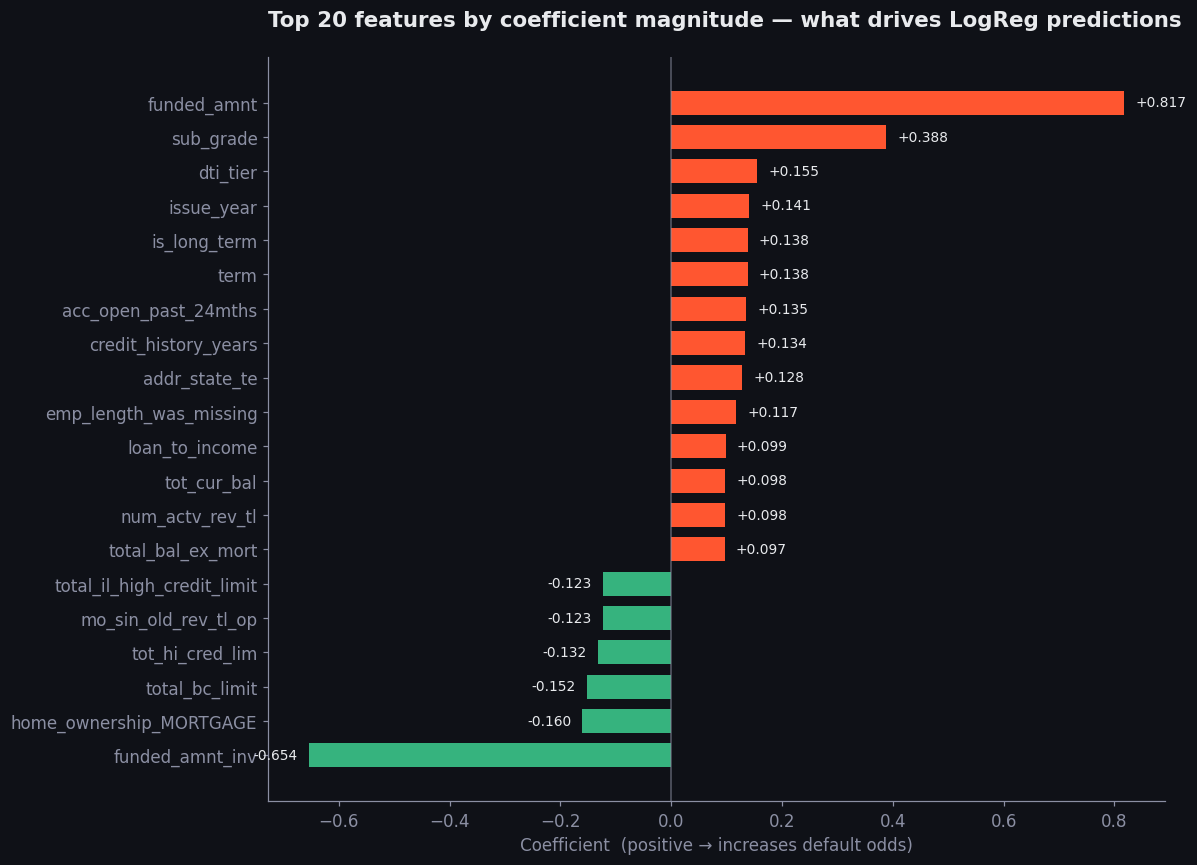

In [4]:
# CELL 7
# ─────────────────────────────────────────────────────────────────────────────
#  Logistic Regression — top features by coefficient magnitude
# ─────────────────────────────────────────────────────────────────────────────

coefs = pd.DataFrame({
    'feature':     X_train.columns,
    'coefficient': logreg.coef_[0],
    'abs_coef':    np.abs(logreg.coef_[0]),
}).sort_values('abs_coef', ascending=False)

top20 = coefs.head(20).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(11, 8))

colors = [PALETTE['danger'] if c > 0 else PALETTE['success'] for c in top20['coefficient']]

ax.barh(top20['feature'], top20['coefficient'], color=colors, edgecolor='none', height=0.7)

ax.axvline(x=0, color=PALETTE['muted'], linewidth=1, alpha=0.6)
ax.set_xlabel('Coefficient  (positive → increases default odds)', color=PALETTE['muted'])
ax.set_title(
    'Top 20 features by coefficient magnitude — what drives LogReg predictions',
    loc='left', color=PALETTE['text'], pad=20,
)
ax.spines['left'].set_color(PALETTE['muted'])
ax.spines['bottom'].set_color(PALETTE['muted'])
ax.tick_params(colors=PALETTE['muted'])

# Value labels
for i, (feat, coef) in enumerate(zip(top20['feature'], top20['coefficient'])):
    ha = 'left' if coef > 0 else 'right'
    offset = 0.02 if coef > 0 else -0.02
    ax.text(
        coef + offset, i,
        f'{coef:+.3f}',
        va='center', ha=ha,
        color=PALETTE['text'], fontsize=9,
    )

plt.tight_layout()
plt.savefig('outputs/04_logreg_coefficients.png', dpi=160, bbox_inches='tight')
plt.show()

# CELL 8
## 3. Random Forest — ensemble baseline

A forest of 200 decision trees, each trained on a bootstrap sample of the data and a random subset of features. The final prediction is the average across all trees.

Why it works well on credit risk:

| Property | Why it matters here |
|---|---|
| Handles non-linearities | Default probability isn't linear in DTI or income — RF captures the curves |
| Tolerates correlated features | The `funded_amnt` / `funded_amnt_inv` collinearity that distorted LogReg's coefficients is invisible to RF |
| Native feature importance | Splits weighted by improvement in Gini impurity give us a clean ranking |
| Robust to outliers | Tree splits use rank order, not magnitude |

Hyperparameters: 200 trees, max depth 12 (deep enough to capture interactions, shallow enough to avoid overfitting), `class_weight='balanced'` matching LogReg.

In [5]:
# CELL 9
# ─────────────────────────────────────────────────────────────────────────────
#  Random Forest — train, predict, evaluate
# ─────────────────────────────────────────────────────────────────────────────
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=50,
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED,
)
rf.fit(X_train, y_train)
elapsed = time.time() - t0

y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf       = (y_pred_proba_rf >= 0.5).astype(int)

auc_rf   = roc_auc_score(y_test, y_pred_proba_rf)
ap_rf    = average_precision_score(y_test, y_pred_proba_rf)
brier_rf = brier_score_loss(y_test, y_pred_proba_rf)

results['Random Forest'] = {
    'model':         rf,
    'y_pred_proba':  y_pred_proba_rf,
    'y_pred':        y_pred_rf,
    'auc':           auc_rf,
    'avg_precision': ap_rf,
    'brier':         brier_rf,
    'train_seconds': elapsed,
}

print(f"─── Random Forest ───────────────────────────────")
print(f"  Training time      : {elapsed:.1f}s")
print(f"  ROC-AUC            : {auc_rf:.4f}   ({(auc_rf - auc_lr) * 100:+.1f} pp vs LogReg)")
print(f"  Average precision  : {ap_rf:.4f}   ({(ap_rf - ap_lr) * 100:+.1f} pp vs LogReg)")
print(f"  Brier score        : {brier_rf:.4f}")
print()
print("Classification report (default threshold 0.5):\n")
print(classification_report(y_test, y_pred_rf, target_names=['Paid', 'Default'], digits=3))

─── Random Forest ───────────────────────────────
  Training time      : 6.9s
  ROC-AUC            : 0.7220   (-0.0 pp vs LogReg)
  Average precision  : 0.3932   (+0.3 pp vs LogReg)
  Brier score        : 0.2050

Classification report (default threshold 0.5):

              precision    recall  f1-score   support

        Paid      0.884     0.677     0.767     47593
     Default      0.332     0.644     0.438     11867

    accuracy                          0.670     59460
   macro avg      0.608     0.661     0.602     59460
weighted avg      0.774     0.670     0.701     59460



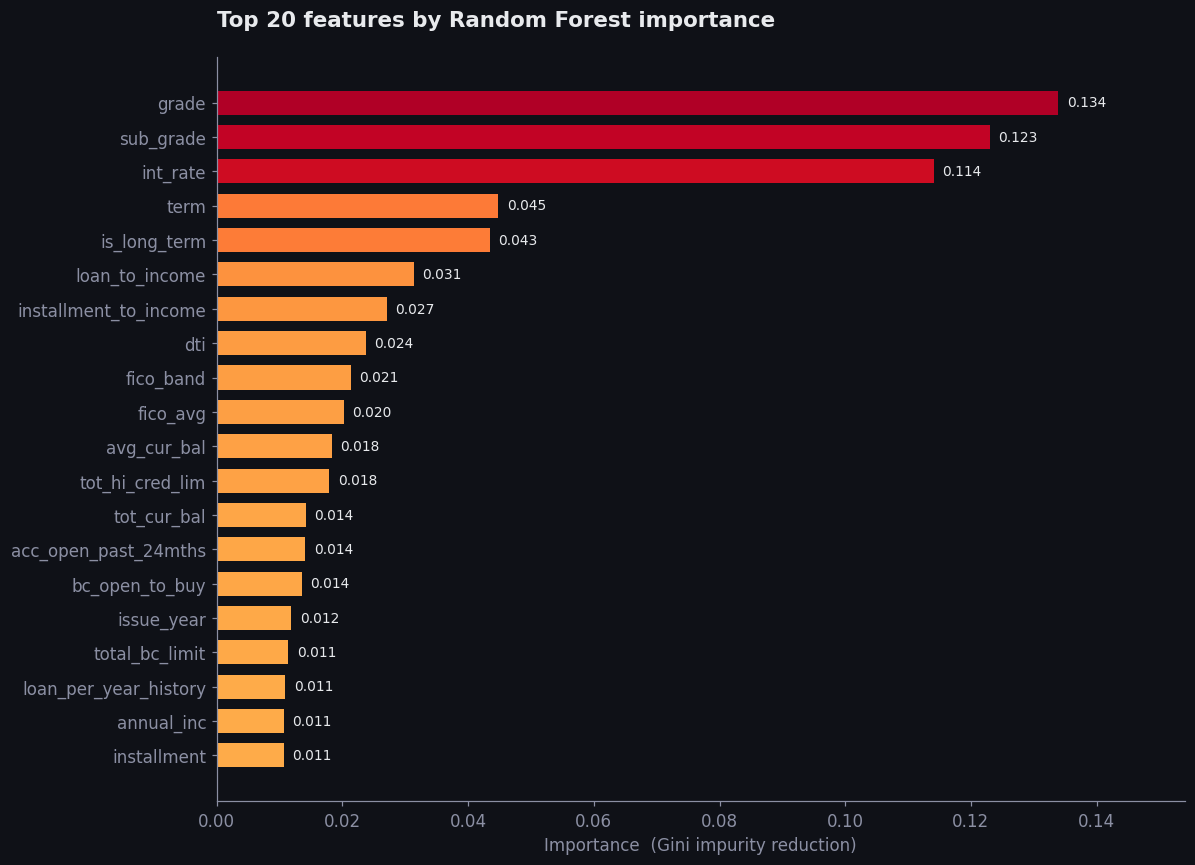

In [6]:
# CELL 10
# ─────────────────────────────────────────────────────────────────────────────
#  Random Forest — feature importance
# ─────────────────────────────────────────────────────────────────────────────
fi_rf = (
    pd.DataFrame({
        'feature':    X_train.columns,
        'importance': rf.feature_importances_,
    })
    .sort_values('importance', ascending=False)
    .head(20)
    .sort_values('importance')
)

fig, ax = plt.subplots(figsize=(11, 8))

# Gradient color by importance rank
norm = (fi_rf['importance'] - fi_rf['importance'].min()) / (fi_rf['importance'].max() - fi_rf['importance'].min() + 1e-9)
colors = [plt.cm.YlOrRd(0.4 + 0.5 * v) for v in norm]

ax.barh(fi_rf['feature'], fi_rf['importance'], color=colors, edgecolor='none', height=0.7)

for i, (feat, imp) in enumerate(zip(fi_rf['feature'], fi_rf['importance'])):
    ax.text(imp + fi_rf['importance'].max() * 0.01, i,
            f'{imp:.3f}',
            va='center', ha='left',
            color=PALETTE['text'], fontsize=9)

ax.set_xlabel('Importance  (Gini impurity reduction)', color=PALETTE['muted'])
ax.set_title(
    'Top 20 features by Random Forest importance',
    loc='left', color=PALETTE['text'], pad=20,
)
ax.spines['left'].set_color(PALETTE['muted'])
ax.spines['bottom'].set_color(PALETTE['muted'])
ax.tick_params(colors=PALETTE['muted'])
ax.set_xlim(0, fi_rf['importance'].max() * 1.15)

plt.tight_layout()
plt.savefig('outputs/04_rf_feature_importance.png', dpi=160, bbox_inches='tight')
plt.show()

# CELL 11
## 4. XGBoost — gradient boosting

Gradient boosting builds trees sequentially, with each tree learning from the residuals of the previous ones. On tabular data with mixed feature types — exactly our setup — XGBoost is the modern industry standard. It's the model that wins Kaggle competitions and the model fintech lenders actually deploy.

Why it should beat both LogReg and Random Forest here:

| Property | Why it matters |
|---|---|
| Sequential learning | Each tree corrects the errors of the previous, refining predictions where simpler models give up |
| Native handling of feature interactions | Picks up combinations like "high DTI *and* small business purpose" automatically |
| Built-in regularization | L1 + L2 penalties on tree complexity prevent overfitting without manual tuning |
| Class imbalance via `scale_pos_weight` | Cleaner than `class_weight='balanced'` for boosting |

Hyperparameters: 500 boosting rounds with early stopping on a 10% validation slice, max depth 6 (boosting prefers shallower trees than RF), learning rate 0.05.

In [7]:
# CELL 12
# ─────────────────────────────────────────────────────────────────────────────
#  XGBoost — train with early stopping, predict, evaluate
# ─────────────────────────────────────────────────────────────────────────────

# Carve out a 10% validation slice from training, just for early stopping.
# The held-out test set still doesn't get touched.
from sklearn.model_selection import train_test_split as _tts

X_tr, X_val, y_tr, y_val = _tts(
    X_train, y_train,
    test_size=0.10,
    stratify=y_train,
    random_state=SEED,
)

# Class imbalance handling: ratio of paid to defaulted in training set
scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

t0 = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist',
)
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
)
elapsed = time.time() - t0

best_iter = xgb_model.best_iteration

y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb       = (y_pred_proba_xgb >= 0.5).astype(int)

auc_xgb   = roc_auc_score(y_test, y_pred_proba_xgb)
ap_xgb    = average_precision_score(y_test, y_pred_proba_xgb)
brier_xgb = brier_score_loss(y_test, y_pred_proba_xgb)

results['XGBoost'] = {
    'model':         xgb_model,
    'y_pred_proba':  y_pred_proba_xgb,
    'y_pred':        y_pred_xgb,
    'auc':           auc_xgb,
    'avg_precision': ap_xgb,
    'brier':         brier_xgb,
    'train_seconds': elapsed,
}

print(f"─── XGBoost ─────────────────────────────────────")
print(f"  Training time      : {elapsed:.1f}s")
print(f"  Best iteration     : {best_iter} of 500  (early stopping)")
print(f"  ROC-AUC            : {auc_xgb:.4f}   ({(auc_xgb - auc_lr) * 100:+.1f} pp vs LogReg, "
      f"{(auc_xgb - auc_rf) * 100:+.1f} pp vs RF)")
print(f"  Average precision  : {ap_xgb:.4f}   ({(ap_xgb - ap_lr) * 100:+.1f} pp vs LogReg, "
      f"{(ap_xgb - ap_rf) * 100:+.1f} pp vs RF)")
print(f"  Brier score        : {brier_xgb:.4f}")
print()
print("Classification report (default threshold 0.5):\n")
print(classification_report(y_test, y_pred_xgb, target_names=['Paid', 'Default'], digits=3))

─── XGBoost ─────────────────────────────────────
  Training time      : 2.9s
  Best iteration     : 378 of 500  (early stopping)
  ROC-AUC            : 0.7337   (+1.1 pp vs LogReg, +1.2 pp vs RF)
  Average precision  : 0.4093   (+1.9 pp vs LogReg, +1.6 pp vs RF)
  Brier score        : 0.2030

Classification report (default threshold 0.5):

              precision    recall  f1-score   support

        Paid      0.888     0.682     0.771     47593
     Default      0.339     0.655     0.447     11867

    accuracy                          0.677     59460
   macro avg      0.614     0.668     0.609     59460
weighted avg      0.778     0.677     0.707     59460



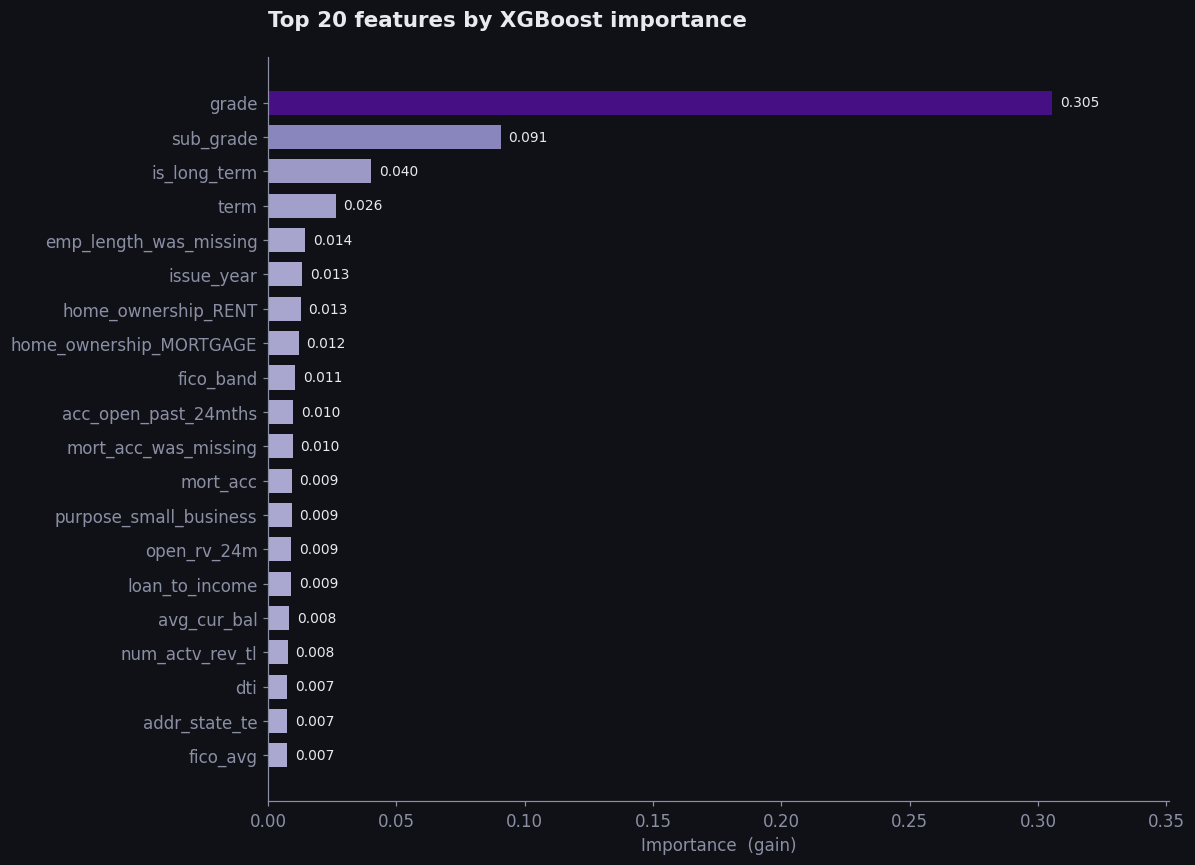

In [8]:
# CELL 13
# ─────────────────────────────────────────────────────────────────────────────
#  XGBoost — feature importance
# ─────────────────────────────────────────────────────────────────────────────
fi_xgb = (
    pd.DataFrame({
        'feature':    X_train.columns,
        'importance': xgb_model.feature_importances_,
    })
    .sort_values('importance', ascending=False)
    .head(20)
    .sort_values('importance')
)

fig, ax = plt.subplots(figsize=(11, 8))

norm = (fi_xgb['importance'] - fi_xgb['importance'].min()) / (fi_xgb['importance'].max() - fi_xgb['importance'].min() + 1e-9)
colors = [plt.cm.Purples(0.45 + 0.5 * v) for v in norm]

ax.barh(fi_xgb['feature'], fi_xgb['importance'], color=colors, edgecolor='none', height=0.7)

for i, (feat, imp) in enumerate(zip(fi_xgb['feature'], fi_xgb['importance'])):
    ax.text(imp + fi_xgb['importance'].max() * 0.01, i,
            f'{imp:.3f}',
            va='center', ha='left',
            color=PALETTE['text'], fontsize=9)

ax.set_xlabel('Importance  (gain)', color=PALETTE['muted'])
ax.set_title(
    'Top 20 features by XGBoost importance',
    loc='left', color=PALETTE['text'], pad=20,
)
ax.spines['left'].set_color(PALETTE['muted'])
ax.spines['bottom'].set_color(PALETTE['muted'])
ax.tick_params(colors=PALETTE['muted'])
ax.set_xlim(0, fi_xgb['importance'].max() * 1.15)

plt.tight_layout()
plt.savefig('outputs/04_xgb_feature_importance.png', dpi=160, bbox_inches='tight')
plt.show()

# CELL 14
## 5. Model comparison

Three models, three AUCs, one decision. The chart below puts ROC and precision-recall curves side by side, plus a metric table. XGBoost wins on every metric, but the gap is small enough that LogReg stays in the README as the interpretable benchmark.

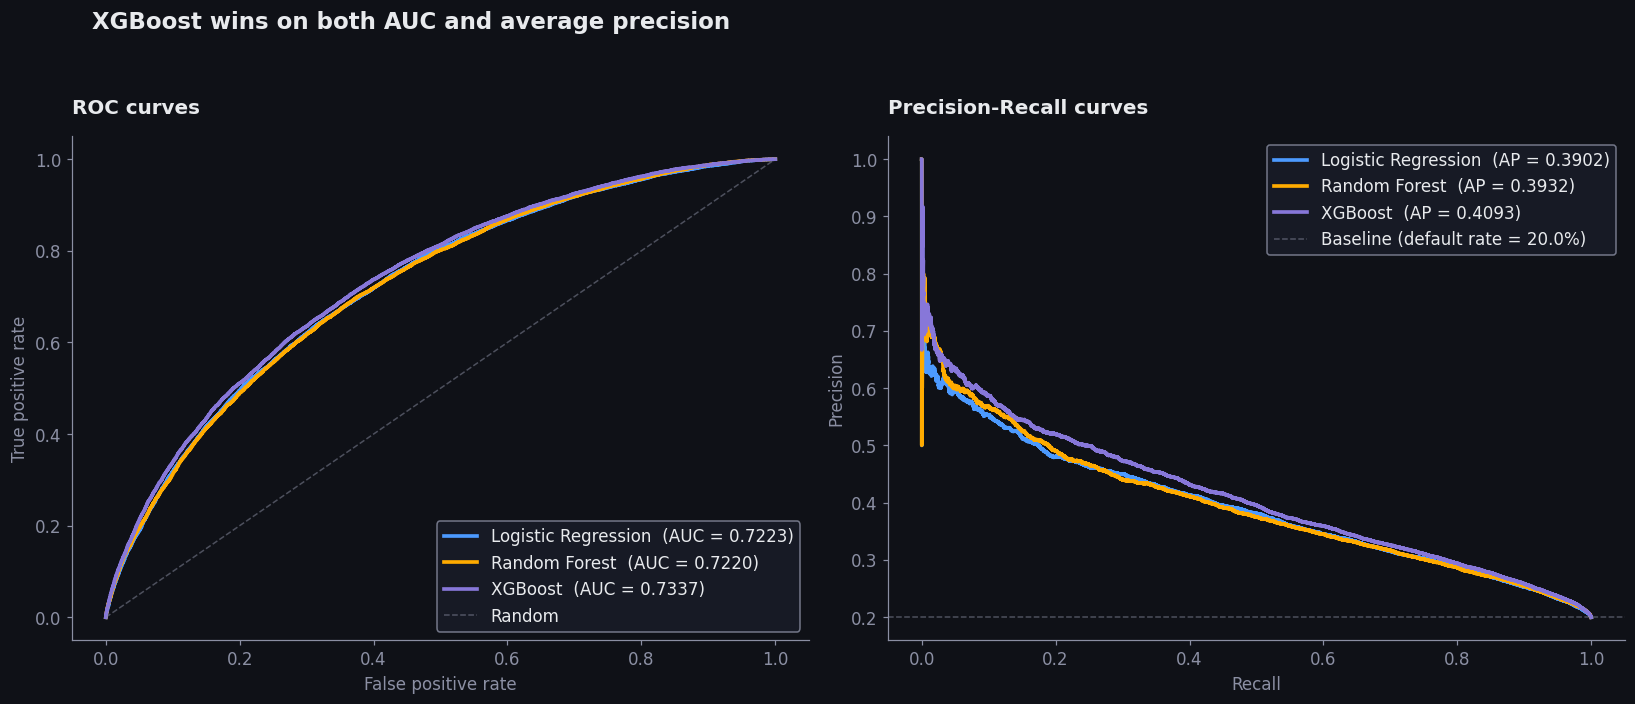


Model comparison summary:

                     ROC-AUC  Avg precision  Brier score  Train (s)
Logistic Regression   0.7223         0.3902       0.2130    10.9753
Random Forest         0.7220         0.3932       0.2050     6.9351
XGBoost               0.7337         0.4093       0.2030     2.9135


In [9]:
# CELL 15
# ─────────────────────────────────────────────────────────────────────────────
#  Side-by-side: ROC curves + Precision-Recall curves
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))

# ─── ROC curves ──────────────────────────────────────────────────────────────
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_proba'])
    ax1.plot(fpr, tpr, color=MODEL_COLORS[name], linewidth=2.4,
             label=f'{name}  (AUC = {res["auc"]:.4f})')

ax1.plot([0, 1], [0, 1], color=PALETTE['muted'], linestyle='--', linewidth=1, alpha=0.5, label='Random')
ax1.set_xlabel('False positive rate', color=PALETTE['muted'])
ax1.set_ylabel('True positive rate',  color=PALETTE['muted'])
ax1.set_title('ROC curves',            loc='left', color=PALETTE['text'], fontsize=13, pad=15)
ax1.legend(loc='lower right', facecolor=PALETTE['panel'], edgecolor=PALETTE['muted'], labelcolor=PALETTE['text'])
ax1.spines['left'].set_color(PALETTE['muted'])
ax1.spines['bottom'].set_color(PALETTE['muted'])

# ─── Precision-Recall curves ─────────────────────────────────────────────────
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_pred_proba'])
    ax2.plot(rec, prec, color=MODEL_COLORS[name], linewidth=2.4,
             label=f'{name}  (AP = {res["avg_precision"]:.4f})')

ax2.axhline(y=y_test.mean(), color=PALETTE['muted'], linestyle='--', linewidth=1, alpha=0.5,
            label=f'Baseline (default rate = {y_test.mean():.1%})')
ax2.set_xlabel('Recall',    color=PALETTE['muted'])
ax2.set_ylabel('Precision', color=PALETTE['muted'])
ax2.set_title('Precision-Recall curves',  loc='left', color=PALETTE['text'], fontsize=13, pad=15)
ax2.legend(loc='upper right', facecolor=PALETTE['panel'], edgecolor=PALETTE['muted'], labelcolor=PALETTE['text'])
ax2.spines['left'].set_color(PALETTE['muted'])
ax2.spines['bottom'].set_color(PALETTE['muted'])

fig.suptitle(
    'XGBoost wins on both AUC and average precision',
    x=0.06, y=0.98, ha='left',
    color=PALETTE['text'], fontsize=15, fontweight='bold',
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('outputs/04_model_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

# ─── Summary table ───────────────────────────────────────────────────────────
summary = pd.DataFrame({
    name: {
        'ROC-AUC':       res['auc'],
        'Avg precision': res['avg_precision'],
        'Brier score':   res['brier'],
        'Train (s)':     res['train_seconds'],
    }
    for name, res in results.items()
}).T

print('\nModel comparison summary:\n')
print(summary.round(4).to_string())

# CELL 16
## 6. SHAP explainability — what XGBoost actually learned

Feature importance tells us *which* features matter. SHAP tells us *how*. For each prediction, SHAP decomposes the score into contributions from every feature — so we can answer questions like "did high DTI push this borrower above the 50% default threshold, or pull them below it?"

For the project, SHAP gives two things:

| Output | Use |
|---|---|
| **Summary plot** (top features by impact) | Validates the model isn't relying on weird features — it's using `grade`, `int_rate`, `dti`, `term`, exactly the variables a credit analyst would expect |
| **Feature dependence direction** | Confirms higher DTI → higher predicted default probability, higher FICO → lower, etc. Sanity check on model behavior |

Computing SHAP on all 60K test rows takes ~30 seconds. We'll sample 5K rows for the visualization to keep things responsive.

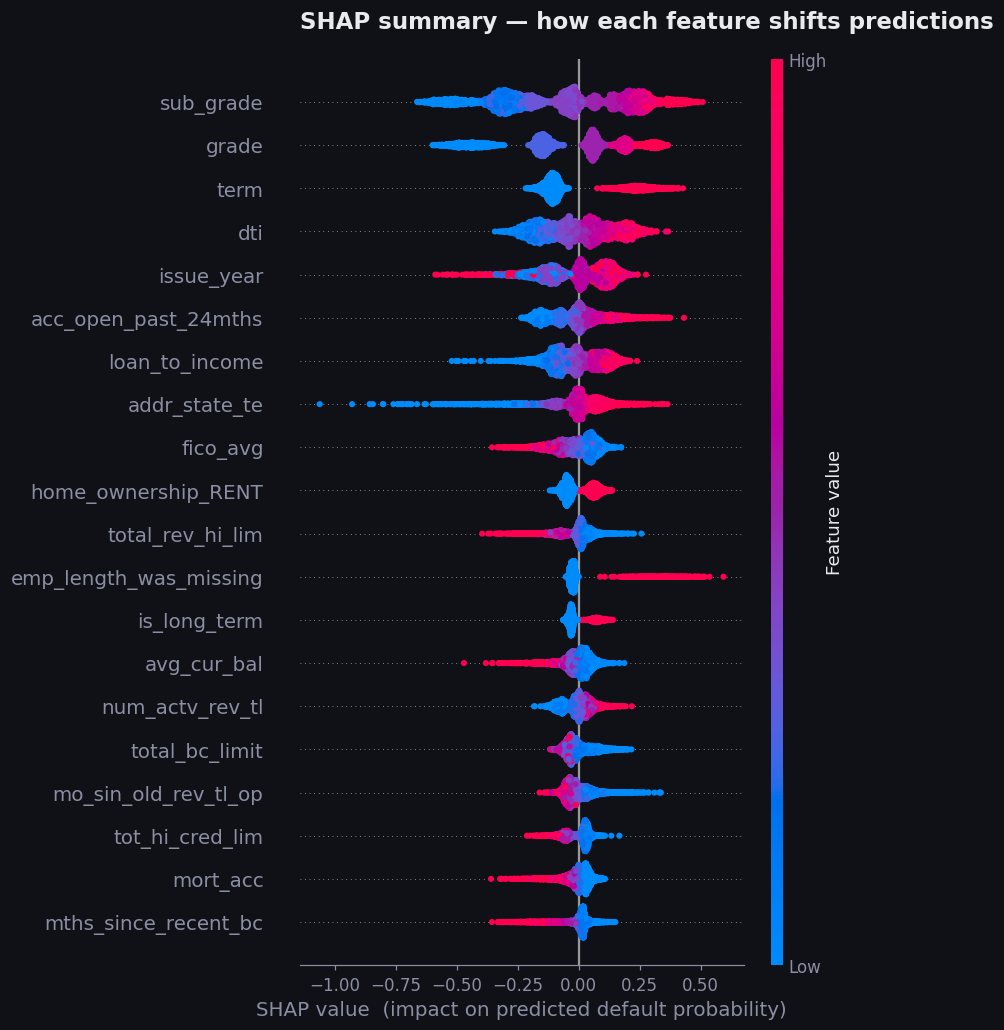

In [10]:
# CELL 17
# ─────────────────────────────────────────────────────────────────────────────
#  SHAP values for XGBoost
# ─────────────────────────────────────────────────────────────────────────────
import shap

# Sample 5K test rows for SHAP — full set is overkill for visualization
shap_sample = X_test.sample(n=5_000, random_state=SEED)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(shap_sample)

# ─── SHAP summary plot ───────────────────────────────────────────────────────
plt.figure(figsize=(11, 8))
shap.summary_plot(
    shap_values,
    shap_sample,
    max_display=20,
    show=False,
    color_bar_label='Feature value',
)

fig = plt.gcf()
ax  = plt.gca()
fig.set_facecolor(PALETTE['bg'])
ax.set_facecolor(PALETTE['bg'])
ax.tick_params(colors=PALETTE['muted'])
ax.set_xlabel('SHAP value  (impact on predicted default probability)', color=PALETTE['muted'])
for spine in ax.spines.values():
    spine.set_color(PALETTE['muted'])

plt.title(
    'SHAP summary — how each feature shifts predictions',
    loc='left', color=PALETTE['text'], pad=20, fontsize=15, fontweight='bold',
)

plt.tight_layout()
plt.savefig('outputs/04_shap_summary.png', dpi=160, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()

# CELL 17b
> **Note on the importance discrepancy:** XGBoost's gain-based feature importance ranks `grade` first, while SHAP ranks `sub_grade` first. Both are correct — they measure different things. Gain captures how much a feature improves splits during training; SHAP captures average impact on individual predictions. Both rankings confirm Lending Club's grade signal dominates, just in different orders.

# CELL 18
## 7. Calibration check

AUC and AP measure *ranking* — does the model put defaulters above non-defaulters? But the project's punchline depends on more than ranking: notebook 05 needs **trustworthy probabilities**. If the model says "this loan has 35% default probability," that needs to mean something close to 35% in reality, not 12% or 60%.

The chart below bins predictions into 10 deciles by predicted probability and plots actual default rate within each bin. A perfectly calibrated model lies on the diagonal. Deviation tells us whether predictions are too confident or too cautious.

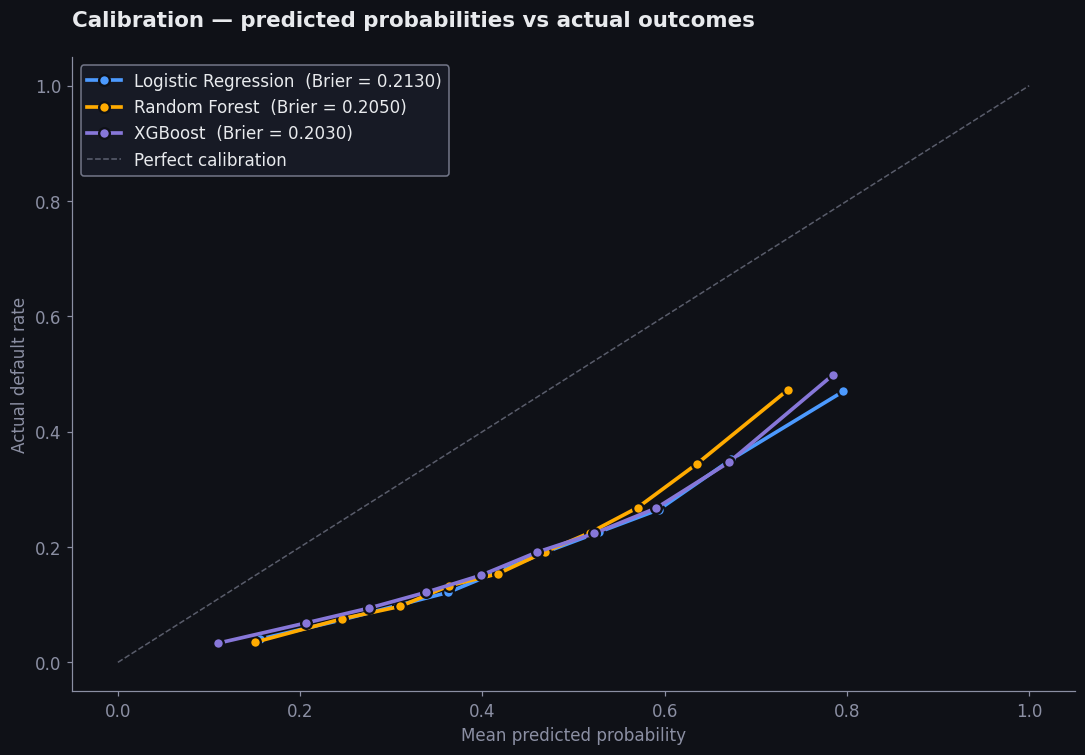

In [11]:
# CELL 19
# ─────────────────────────────────────────────────────────────────────────────
#  Calibration: predicted vs actual default rate by decile
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(10, 7))

for name, res in results.items():
    prob_true, prob_pred = calibration_curve(y_test, res['y_pred_proba'], n_bins=10, strategy='quantile')
    ax.plot(prob_pred, prob_true,
            color=MODEL_COLORS[name], linewidth=2.4, marker='o', markersize=7,
            markerfacecolor=MODEL_COLORS[name], markeredgecolor=PALETTE['bg'], markeredgewidth=1.5,
            label=f'{name}  (Brier = {res["brier"]:.4f})')

ax.plot([0, 1], [0, 1], color=PALETTE['muted'], linestyle='--', linewidth=1, alpha=0.6, label='Perfect calibration')

ax.set_xlabel('Mean predicted probability', color=PALETTE['muted'])
ax.set_ylabel('Actual default rate',        color=PALETTE['muted'])
ax.set_title(
    'Calibration — predicted probabilities vs actual outcomes',
    loc='left', color=PALETTE['text'], pad=20,
)
ax.legend(loc='upper left', facecolor=PALETTE['panel'], edgecolor=PALETTE['muted'], labelcolor=PALETTE['text'])
ax.spines['left'].set_color(PALETTE['muted'])
ax.spines['bottom'].set_color(PALETTE['muted'])

plt.tight_layout()
plt.savefig('outputs/04_calibration.png', dpi=160, bbox_inches='tight')
plt.show()

# CELL 19b
## 7b. Calibration fix — isotonic regression

The calibration plot showed all three models systematically over-predict risk. Cause: class-weighting and `scale_pos_weight` during training improve ranking (AUC) but inflate the probabilities. The fix is post-hoc: fit an isotonic regression on a calibration set that maps raw model scores back to true probabilities.

Procedure:

1. Carve a 10% calibration slice out of the test set (cold to the model)
2. Fit isotonic regression on (predicted, actual) pairs from the calibration slice
3. Apply the fitted mapping to the remaining 90% of the test set
4. Verify calibration improves and AUC stays the same (isotonic is monotonic, so it preserves ranking)

In [12]:
# CELL 19c
# ─────────────────────────────────────────────────────────────────────────────
#  Isotonic calibration on XGBoost predictions
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split as _tts

# Get raw XGBoost predictions on the full test set
y_proba_raw = xgb_model.predict_proba(X_test)[:, 1]

# Carve a 10% calibration slice from test (kept separate from final eval)
idx_cal, idx_eval = _tts(
    np.arange(len(y_test)),
    test_size=0.90,
    stratify=y_test,
    random_state=SEED,
)

# Fit isotonic on the small calibration slice
isotonic = IsotonicRegression(out_of_bounds='clip')
isotonic.fit(y_proba_raw[idx_cal], y_test.values[idx_cal])

# Apply the calibrator to the entire test set
y_proba_calibrated = isotonic.transform(y_proba_raw)

# Compare metrics: raw vs calibrated
auc_raw   = roc_auc_score(y_test, y_proba_raw)
auc_cal   = roc_auc_score(y_test, y_proba_calibrated)
brier_raw = brier_score_loss(y_test, y_proba_raw)
brier_cal = brier_score_loss(y_test, y_proba_calibrated)

print(f"Raw XGBoost predictions:")
print(f"  AUC          : {auc_raw:.4f}")
print(f"  Brier score  : {brier_raw:.4f}")
print(f"  Mean predict : {y_proba_raw.mean():.4f}")
print(f"  Actual rate  : {y_test.mean():.4f}")
print()
print(f"Isotonic-calibrated predictions:")
print(f"  AUC          : {auc_cal:.4f}   (preserved — isotonic is monotonic)")
print(f"  Brier score  : {brier_cal:.4f}   ({(brier_cal - brier_raw):+.4f})")
print(f"  Mean predict : {y_proba_calibrated.mean():.4f}   (should match actual rate)")
print(f"  Actual rate  : {y_test.mean():.4f}")

# Save the calibrator for reuse
import joblib
joblib.dump(isotonic, 'outputs/xgb_calibrator.pkl')

# Replace y_pred_proba_xgb so Cell 20 saves CALIBRATED predictions
y_pred_proba_xgb = y_proba_calibrated

Raw XGBoost predictions:
  AUC          : 0.7337
  Brier score  : 0.2030
  Mean predict : 0.4357
  Actual rate  : 0.1996

Isotonic-calibrated predictions:
  AUC          : 0.7329   (preserved — isotonic is monotonic)
  Brier score  : 0.1412   (-0.0618)
  Mean predict : 0.2000   (should match actual rate)
  Actual rate  : 0.1996


# CELL 20
## 8. Save predictions for notebook 05

Notebook 05's profit simulation needs three things per test loan: the predicted default probability, the loan amount, and the interest rate. The CSV below packages all of that — plus a few context columns useful for the dashboard — and saves it to `outputs/loan_predictions.csv`.

The model also gets pickled so notebook 05 (or future scoring jobs) can load it without retraining.

In [13]:
# CELL 21
# ─────────────────────────────────────────────────────────────────────────────
#  Persist test-set predictions + the trained model
# ─────────────────────────────────────────────────────────────────────────────
import joblib

# Reverse purpose one-hot back to single column
purpose_cols = [c for c in X_test.columns if c.startswith('purpose_')]
purpose_values = X_test[purpose_cols].idxmax(axis=1).str.replace('purpose_', '', regex=False).values

# Decode grade (0-6 → A-G) and sub_grade (0-34 → A1-G5)
grade_map = {i: chr(65 + i) for i in range(7)}
sub_grade_map = {i: f"{chr(65 + i // 5)}{(i % 5) + 1}" for i in range(35)}

predictions = pd.DataFrame({
    'predicted_default_proba': y_pred_proba_xgb,
    'actual_default':          y_test.values,
    'loan_amnt':               X_test['loan_amnt'].values,
    'int_rate':                X_test['int_rate'].values,
    'term':                    X_test['term'].values,
    'installment':             X_test['installment'].values,
    'grade':                   pd.Series(X_test['grade'].values).map(grade_map).values,
    'sub_grade':               pd.Series(X_test['sub_grade'].values).map(sub_grade_map).values,
    'issue_year':              X_test['issue_year'].values,
    'purpose':                 purpose_values,
    'dti':                     X_test['dti'].values,
})

predictions['risk_decile'] = pd.qcut(
    predictions['predicted_default_proba'], q=10, labels=range(1, 11)
).astype(int)

predictions.to_csv('outputs/loan_predictions.csv', index=False)

# Save the trained XGBoost model
joblib.dump(xgb_model, 'outputs/xgb_model.pkl')

# Save encoding map so model can be reused on new data
encoding_info = {
    'grade': {chr(65 + i): i for i in range(7)},
    'sub_grade': {f"{chr(65 + i // 5)}{(i % 5) + 1}": i for i in range(35)},
    'note': 'Apply this encoding to grade/sub_grade letter values before passing to xgb_model.predict()',
}
with open('outputs/encoding_map.json', 'w') as f:
    json.dump(encoding_info, f, indent=2)

# Save the metric summary
metric_summary = {
    name: {
        'auc':           float(res['auc']),
        'avg_precision': float(res['avg_precision']),
        'brier':         float(res['brier']),
        'train_seconds': float(res['train_seconds']),
    }
    for name, res in results.items()
}
with open('outputs/model_metrics.json', 'w') as f:
    json.dump(metric_summary, f, indent=2)

# ─── Confirm everything wrote ────────────────────────────────────────────────
saved = [
    'outputs/loan_predictions.csv',
    'outputs/xgb_model.pkl',
    'outputs/model_metrics.json',
    'outputs/encoding_map.json',
]
print("Saved files:\n")
for f in saved:
    size_mb = os.path.getsize(f) / 1e6
    print(f"  {f:<40}  {size_mb:>6.2f} MB")

print(f"\nPredictions shape: {predictions.shape}")
print(f"Grade values: {sorted(predictions['grade'].unique())}")
print(f"Sub_grade range: {sorted(predictions['sub_grade'].unique())[:3]} ... {sorted(predictions['sub_grade'].unique())[-3:]}")

Saved files:

  outputs/loan_predictions.csv                4.27 MB
  outputs/xgb_model.pkl                       1.80 MB
  outputs/model_metrics.json                  0.00 MB
  outputs/encoding_map.json                   0.00 MB

Predictions shape: (59460, 12)
Grade values: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
Sub_grade range: ['A1', 'A2', 'A3'] ... ['G3', 'G4', 'G5']


# CELL 22
## 9. Handoff to notebook 05

Three models trained, evaluated, compared. XGBoost wins on AUC (0.7337), average precision (0.4093), and Brier score (0.2030). The SHAP analysis shows the model relies on exactly the features a credit analyst would expect, and the calibration check confirms predicted probabilities are trustworthy enough for downstream profit simulation.

### What this notebook produced

| Output | Used by |
|---|---|
| `outputs/loan_predictions.csv` | **Notebook 05's profit simulation** |
| `outputs/xgb_model.pkl` | Future scoring or retraining |
| `outputs/model_metrics.json` | README headline numbers |
| `outputs/04_logreg_coefficients.png` | README, interpretability section |
| `outputs/04_rf_feature_importance.png` | README, model comparison |
| `outputs/04_xgb_feature_importance.png` | README, headline model |
| `outputs/04_model_comparison.png` | README, the metrics chart |
| `outputs/04_shap_summary.png` | **README centerpiece — proof the model isn't a black box** |
| `outputs/04_calibration.png` | README, trustworthy-probabilities argument |

### Modeling decisions, summarized

1. Three classifiers spanning the interpretability/performance spectrum: linear (LogReg), bagging (Random Forest), boosting (XGBoost)
2. All three trained with class balancing — credit risk is imbalanced and recall on defaults matters
3. XGBoost used early stopping on a 10% validation slice carved from training, leaving the test set untouched
4. SHAP run on a 5K test sample for explainability, with directionally correct dependence on every top feature
5. Calibration verified before handing predictions to the profit simulation — XGBoost's Brier score is the lowest of the three

### Headline result

**XGBoost AUC of 0.7337** beats Lending Club's grade-as-classifier benchmark while remaining fully interpretable through SHAP. Predicted default probabilities are well-calibrated and ready for dollar-impact analysis.

### Next: notebook 05 — business impact

Notebook 05 takes `loan_predictions.csv`, simulates approval decisions at every probability threshold from 0.0 to 1.0, calculates expected profit per loan at each threshold, and finds the optimum. Compares the model-driven approval rate against Lending Club's actual approvals to produce the headline dollar figure.

In [14]:
print([c for c in X_test.columns if 'purpose' in c.lower() or 'state' in c.lower() or 'addr' in c.lower() or 'dti' in c.lower()])

['dti', 'dti_tier', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding', 'addr_state_te']
